=== Tuning Dataset 1 (Blobs) ===
LR=0.001: Validation Acc=1.0000, Final Cost=0.0996
LR=0.01: Validation Acc=1.0000, Final Cost=0.0262
LR=0.1: Validation Acc=1.0000, Final Cost=0.0131
LR=0.5: Validation Acc=1.0000, Final Cost=0.0113
LR=1.0: Validation Acc=1.0000, Final Cost=0.0110

Dataset 1 best learning rate: 1.0, Best Val Acc: 1.0000, Best Cost: 0.0110

=== Tuning Dataset 2 (Circles) ===
LR=0.001: Validation Acc=0.6000, Final Cost=0.6921
LR=0.01: Validation Acc=0.4800, Final Cost=0.6915
Converged at iteration 1548
LR=0.1: Validation Acc=0.4667, Final Cost=0.6915
Converged at iteration 305
LR=0.5: Validation Acc=0.4667, Final Cost=0.6915
Converged at iteration 150
LR=1.0: Validation Acc=0.4667, Final Cost=0.6915

Dataset 2 best learning rate: 0.001, Best Val Acc: 0.6000, Best Cost: 0.6921

=== Final Test Results ===
Dataset 1 Test Accuracy: 1.0000
Dataset 2 Test Accuracy: 0.5067


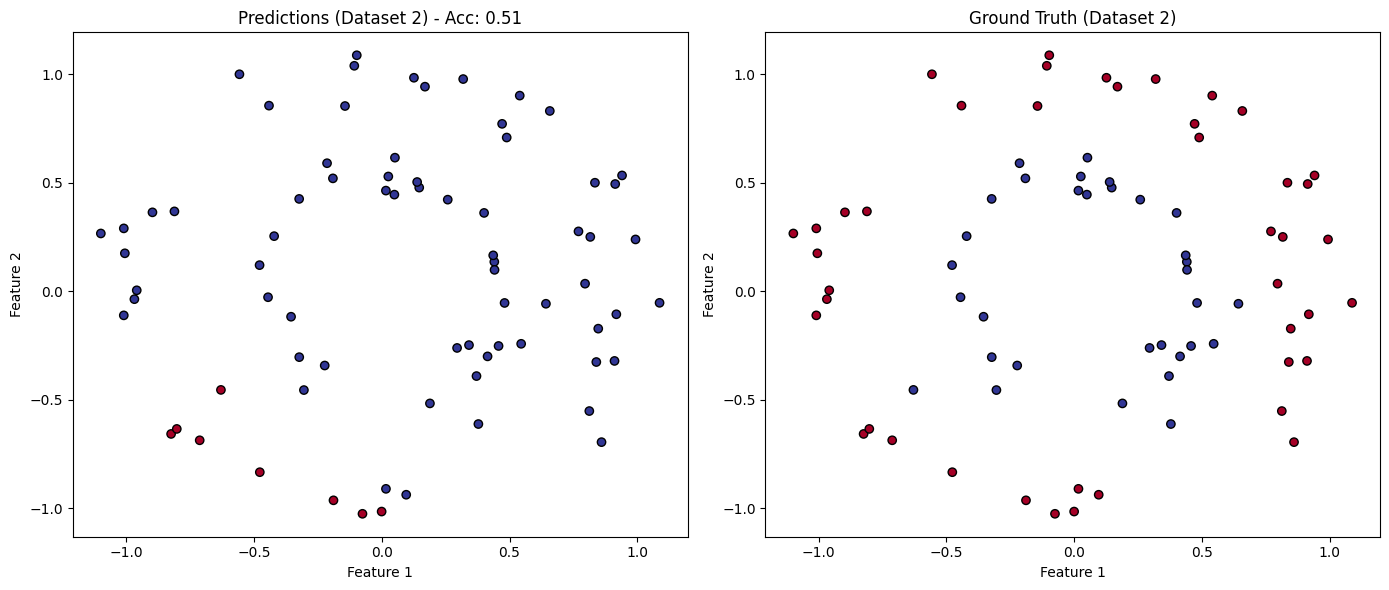

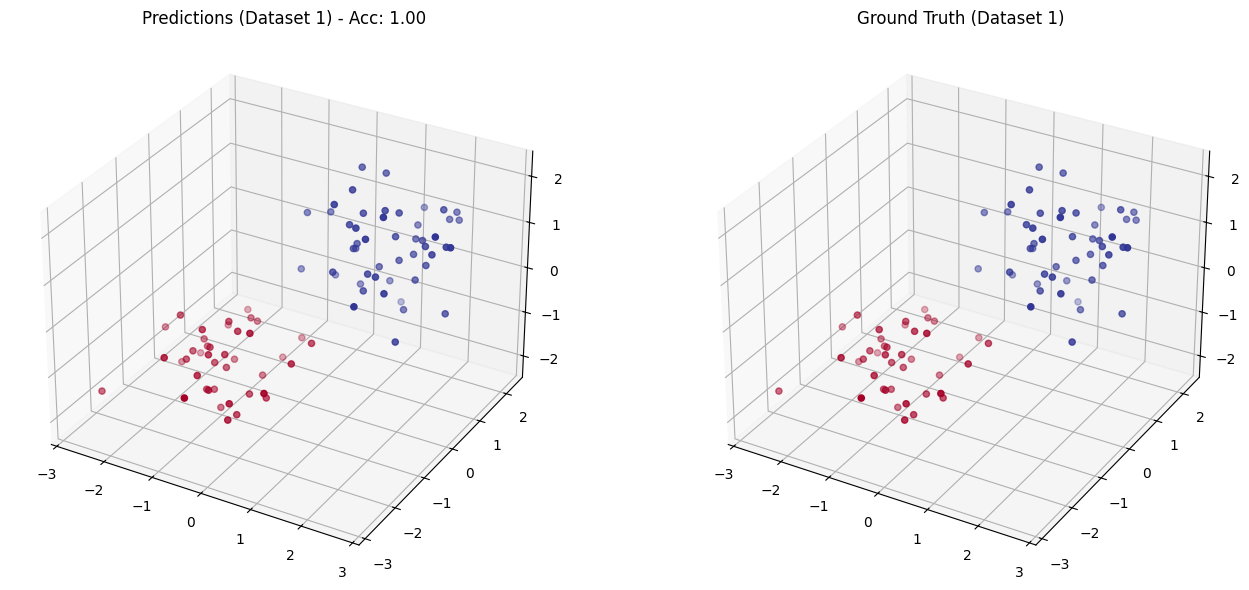

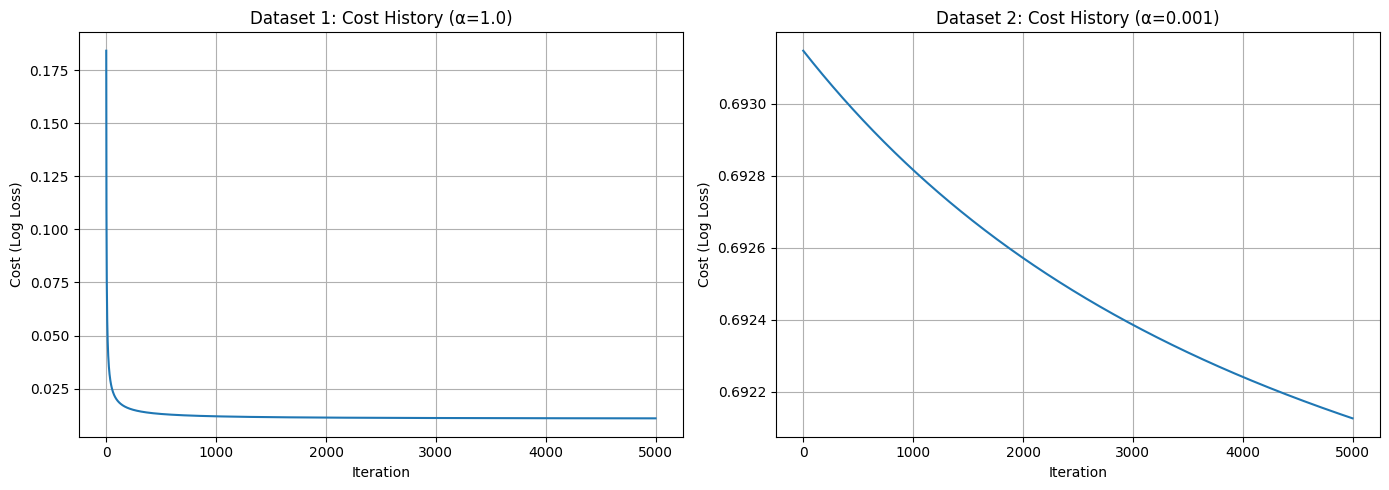

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import pandas as pd
import numpy as np
%matplotlib inline

def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

def calculate_gradient(theta, X_b, y):  # Fixed typo
    m = y.size
    y_hat = sigmoid(X_b @ theta)
    gradient = (1 / m) * (X_b.T @ (y_hat - y))
    return gradient 

def gradient_descent(X, y, alpha=0.1, num_iter=1000, tol=1e-7):  # Increased default iterations
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    theta = np.zeros(X_b.shape[1])

    cost_history = []

    for i in range(num_iter):
        grad = calculate_gradient(theta, X_b, y)  # Fixed typo
        theta -= alpha * grad

        cost = compute_cost(theta, X_b, y)
        cost_history.append(cost)

        if np.linalg.norm(grad) < tol:
            print(f"Converged at iteration {i}")
            break

    return theta, cost_history

def predict_proba(X, theta):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    return sigmoid(X_b @ theta)

def predict(X, theta, threshold=0.5):
    return (predict_proba(X, theta) >= threshold).astype(int)

def compute_cost(theta, X_b, y):
    m = y.size
    y_hat = sigmoid(X_b @ theta)
    eps = 1e-9
    cost = -(1 / m) * np.sum(
        y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps)
    )
    return cost

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# Load datasets
df1 = pd.read_csv("blobs600.csv")
y1 = df1['Class'].values
del df1['Class']
X1 = df1.values

df2 = pd.read_csv("circles500.csv")
y2 = df2['Class'].values
del df2['Class']
X2 = df2.values

def split_dataset(X, y, train_ratio=0.7, val_ratio=0.15, seed=42):
    np.random.seed(seed)
    m = X.shape[0]
    indices = np.random.permutation(m)

    train_end = int(train_ratio * m)
    val_end = int((train_ratio + val_ratio) * m)

    train_idx = indices[:train_end]
    val_idx = indices[train_end:val_end]
    test_idx = indices[val_end:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    return X_train, y_train, X_val, y_val, X_test, y_test

# Split datasets
X1_train, y1_train, X1_val, y1_val, X1_test, y1_test = split_dataset(X1, y1)
X2_train, y2_train, X2_val, y2_val, X2_test, y2_test = split_dataset(X2, y2)

# Tune learning rate for Dataset 1
# Tune learning rate for Dataset 1
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
num_iterations = 5000

print("=== Tuning Dataset 1 (Blobs) ===")
best_lr_1 = None
best_acc_1 = 0
best_cost_1 = float('inf')

for lr in learning_rates:
    theta, cost_history = gradient_descent(X1_train, y1_train, alpha=lr, num_iter=num_iterations)
    preds = predict(X1_val, theta)
    acc = accuracy(y1_val, preds)
    final_cost = cost_history[-1]
    print(f"LR={lr}: Validation Acc={acc:.4f}, Final Cost={final_cost:.4f}")
    
    # Select based on: (1) better accuracy, OR (2) same accuracy but lower cost
    if acc > best_acc_1 or (acc == best_acc_1 and final_cost < best_cost_1):
        best_acc_1 = acc
        best_lr_1 = lr
        best_cost_1 = final_cost

print(f"\nDataset 1 best learning rate: {best_lr_1}, Best Val Acc: {best_acc_1:.4f}, Best Cost: {best_cost_1:.4f}")
# Tune learning rate for Dataset 2
# Tune learning rate for Dataset 2
print("\n=== Tuning Dataset 2 (Circles) ===")
best_lr_2 = None
best_acc_2 = 0
best_cost_2 = float('inf')

for lr in learning_rates:
    theta, cost_history = gradient_descent(X2_train, y2_train, alpha=lr, num_iter=num_iterations)
    preds = predict(X2_val, theta)
    acc = accuracy(y2_val, preds)
    final_cost = cost_history[-1]
    print(f"LR={lr}: Validation Acc={acc:.4f}, Final Cost={final_cost:.4f}")
    
    # Select based on: (1) better accuracy, OR (2) same accuracy but lower cost
    if acc > best_acc_2 or (acc == best_acc_2 and final_cost < best_cost_2):
        best_acc_2 = acc
        best_lr_2 = lr
        best_cost_2 = final_cost

print(f"\nDataset 2 best learning rate: {best_lr_2}, Best Val Acc: {best_acc_2:.4f}, Best Cost: {best_cost_2:.4f}")

# Train final models and evaluate on test set
print("\n=== Final Test Results ===")
theta1, cost_history1 = gradient_descent(X1_train, y1_train, alpha=best_lr_1, num_iter=num_iterations)
test_preds_1 = predict(X1_test, theta1)
test_acc_1 = accuracy(y1_test, test_preds_1)
print(f"Dataset 1 Test Accuracy: {test_acc_1:.4f}")

theta2, cost_history2 = gradient_descent(X2_train, y2_train, alpha=best_lr_2, num_iter=num_iterations)
test_preds_2 = predict(X2_test, theta2)
test_acc_2 = accuracy(y2_test, test_preds_2)
print(f"Dataset 2 Test Accuracy: {test_acc_2:.4f}")

# Plot predictions for Dataset 2
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Predictions
ax[0].scatter(X2_test[:, 0], X2_test[:, 1], c=test_preds_2, cmap="RdYlBu", edgecolors="k")
ax[0].set_title(f"Predictions (Dataset 2) - Acc: {test_acc_2:.2f}")
ax[0].set_xlabel("Feature 1")
ax[0].set_ylabel("Feature 2")

# Ground truth
ax[1].scatter(X2_test[:, 0], X2_test[:, 1], c=y2_test, cmap="RdYlBu", edgecolors="k")
ax[1].set_title("Ground Truth (Dataset 2)")
ax[1].set_xlabel("Feature 1")
ax[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

# Plot predictions for Dataset 1
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(X1_test[:, 0], X1_test[:, 1], X1_test[:, 2], c=test_preds_1, cmap="RdYlBu")
ax1.set_title(f"Predictions (Dataset 1) - Acc: {test_acc_1:.2f}")

ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(X1_test[:, 0], X1_test[:, 1], X1_test[:, 2], c=y1_test, cmap="RdYlBu")
ax2.set_title("Ground Truth (Dataset 1)")

plt.tight_layout()
plt.show()

# Plot cost history
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(len(cost_history1)), cost_history1)
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Cost (Log Loss)")
ax[0].set_title(f"Dataset 1: Cost History (α={best_lr_1})")
ax[0].grid(True)

ax[1].plot(range(len(cost_history2)), cost_history2)
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Cost (Log Loss)")
ax[1].set_title(f"Dataset 2: Cost History (α={best_lr_2})")
ax[1].grid(True)

plt.tight_layout()
plt.show()